# 3

In [ ]:
python -m pip install -U langchain langchain-core langchain-groq langserve fastapi uvicorn jsonpatch sniffio requests-toolbelt tenacity

import os
from fastapi import FastAPI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq
from langserve import add_routes

os.environ["GROQ_API_KEY"] = "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"

prompt = ChatPromptTemplate.from_template("Answer briefly: {question}")

llm = ChatGroq(model="openai/gpt-oss-20b")

chain = prompt | llm | StrOutputParser()

app = FastAPI(title="Agentic AI API")

add_routes(app, chain, path="/chat")



#save as app.py
#python -m uvicorn app:app

# 4

In [4]:
import os
os.environ["GROQ_API_KEY"] = "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"

import subprocess
import sys
import tempfile
from pathlib import Path

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq


# LLM
llm = ChatGroq(model="openai/gpt-oss-20b")


# Generate code
generate = ChatPromptTemplate.from_template(
    "Write only Python code for this task: {task}"
) | llm | StrOutputParser()


# Fix code
repair = ChatPromptTemplate.from_template(
    "Fix this Python code. Return code only.\nCode:\n{code}\nError:\n{error}"
) | llm | StrOutputParser()


# Remove ```python ``` from LLM response
def clean(code):
    return code.replace("```python", "").replace("```", "").strip()


# Run Python code
def run(code):
    path = Path(tempfile.gettempdir()) / "agent_answer.py"
    path.write_text(code)

    return subprocess.run(
        [sys.executable, str(path)],
        capture_output=True,
        text=True
    )


# Generate first code
code = clean(
    generate.invoke({
        "task": "Print the factorial of 5."
    })
)


# Self-correction loop
for attempt in range(1, 4):

    print(f"\nAttempt {attempt}:")
    print(code)

    result = run(code)

    if result.returncode == 0:
        print("\nOUTPUT:")
        print(result.stdout)

        print("FINAL CODE:")
        print(code)
        break

    print("\nERROR:")
    print(result.stderr)

    code = clean(
        repair.invoke({
            "code": code,
            "error": result.stderr
        })
    )


Attempt 1:
import math
print(math.factorial(5))

OUTPUT:
120

FINAL CODE:
import math
print(math.factorial(5))


# 5

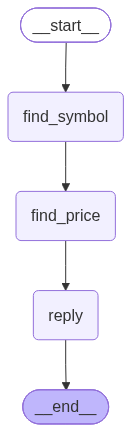

MSFT price: $420.10


In [6]:
# API Key
import os
os.environ["GROQ_API_KEY"] = "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"

# Imports
from typing import TypedDict
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph


# State
class FinanceState(TypedDict):
    question: str
    symbol: str
    price: float
    answer: str


# Find stock symbol
def find_symbol(state):
    text = state["question"].upper()

    symbol = next(
        (s for s in ["AAPL", "TSLA", "MSFT"] if s in text),
        "UNKNOWN"
    )

    return {"symbol": symbol}


# Find stock price
def find_price(state):
    prices = {
        "AAPL": 195.5,
        "TSLA": 180.25,
        "MSFT": 420.1,
        "UNKNOWN": 0
    }

    return {"price": prices[state["symbol"]]}


# Create answer
def reply(state):
    return {
        "answer": f"{state['symbol']} price: ${state['price']:.2f}"
    }


# Build LangGraph
graph = StateGraph(FinanceState)

graph.add_sequence([
    find_symbol,
    find_price,
    reply
])

graph.add_edge(START, "find_symbol")
graph.add_edge("reply", END)


# Compile graph
bot = graph.compile()


# Display graph
display(Image(bot.get_graph().draw_mermaid_png()))


# Run Finance Bot
print(
    bot.invoke({
        "question": "Price of MSFT?"
    })["answer"]
)